## Spam detection in emails project

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from nltk import word_tokenize

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Embedding, Dense, Input, SimpleRNN, LSTM, GRU, Attention, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.text import Tokenizer 
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [4]:
data1 = pd.read_csv("/mnt/c/Users/User/Downloads/Telegram Desktop/spam.csv", encoding = 'latin-1')
data1.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
data2 = pd.read_csv("/mnt/c/Users/User/Downloads/Telegram Desktop/spam_dataset.csv", encoding = 'latin-1')
data2.head()

,message_content,is_spam
0,"Hello Lonnie,\n\nJust wanted to touch base reg...",0
1,"Congratulations, you've won a prize! Call us n...",1
2,You have been pre-approved for a credit card w...,1
3,"Limited time offer, act now! Only a few spots ...",1
4,Your loan has been approved! Transfer funds to...,1


In [6]:
data3 = pd.read_csv("/mnt/c/Users/User/Downloads/Telegram Desktop/spam_ham_dataset.csv", encoding = 'latin-1')
data3.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [7]:
data1.v1 = (data1.v1 == 'spam').astype('int8')

In [8]:
data3.label_num.value_counts()

label_num
0    3672
1    1499
Name: count, dtype: int64

### Merged the three datasets into one

In [9]:
data = pd.DataFrame(data = {'label':np.concatenate((data1.v1 ,data2.is_spam, data3.label_num),axis=0),'text':np.concatenate((data1.v2 ,data2.message_content, data3.text),axis=0)})

In [10]:
data.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
data.label.value_counts().values

array([8997, 2746])

In [12]:
x, y = data.text.values, data.label

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify = y, test_size=0.2, random_state=0)

In [14]:
vec = TfidfVectorizer()
x_train_tokenized = vec.fit_transform(x_train)
x_test_tokenized = vec.transform(x_test)

In [15]:
model = LogisticRegression()
model.fit(x_train_tokenized, y_train)
print(classification_report(y_test, model.predict(x_test_tokenized)))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1800
           1       0.97      0.82      0.89       549

    accuracy                           0.95      2349
   macro avg       0.96      0.91      0.93      2349
weighted avg       0.95      0.95      0.95      2349



In [16]:
def preprocess(text):
    text = "".join([i for i in text.lower() if i.isalpha() or i==' ' or i=="'"])
    text = " ".join(word_tokenize(text))
    return text

In [17]:
max_words = 10000
max_len = 150

In [18]:
model_rnn = Sequential([Embedding(input_dim = max_words, output_dim = 64),
                       SimpleRNN(64, dropout = 0.2),
                       Dense(1, activation = 'sigmoid')])
model_lstm = Sequential([Embedding(input_dim = max_words, output_dim = 64),
                        LSTM(64, dropout = 0.2),
                        Dense(1, activation = 'sigmoid')])
model_gru = Sequential([Embedding(input_dim = max_words, output_dim = 64),
                        GRU(64, dropout = 0.2),
                        Dense(1, activation = 'sigmoid')])

E0000 00:00:1782395095.603670   20685 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [19]:
tokenizer = Tokenizer(num_words = max_words)
tokenizer.fit_on_texts(x_train)
x_train_seq = pad_sequences(tokenizer.texts_to_sequences(x_train), maxlen = max_len, padding = 'post')
x_test_seq = pad_sequences(tokenizer.texts_to_sequences(x_test), maxlen = max_len, padding = 'post')

In [20]:
model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics = ['accuracy'])
his1 = model_rnn.fit(x_train_seq, y_train, batch_size = 32, epochs = 10, validation_data = (x_test_seq, y_test))


Epoch 1/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.7702 - loss: 0.5357 - val_accuracy: 0.7705 - val_loss: 0.5258
Epoch 2/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.7931 - loss: 0.4976 - val_accuracy: 0.7744 - val_loss: 0.5127
Epoch 3/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.7975 - loss: 0.4818 - val_accuracy: 0.7722 - val_loss: 0.5227
Epoch 4/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.8007 - loss: 0.4738 - val_accuracy: 0.7722 - val_loss: 0.5251
Epoch 5/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.7982 - loss: 0.4763 - val_accuracy: 0.7799 - val_loss: 0.5104
Epoch 6/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.7986 - loss: 0.4762 - val_accuracy: 0.7739 - val_loss: 0.5170
Epoch 7/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.8010 - loss: 0.4701 - val_accuracy: 0.7748 - val_loss: 0.5192
Epoch 8/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.7966 - loss: 0.4797 - 

In [21]:
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics = ['accuracy'])
his2 = model_lstm.fit(x_train_seq, y_train, batch_size = 64, epochs = 10, validation_data = (x_test_seq, y_test))

Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 14s 83ms/step - accuracy: 0.7677 - loss: 0.5441 - val_accuracy: 0.7867 - val_loss: 0.5131
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - accuracy: 0.8447 - loss: 0.3874 - val_accuracy: 0.8310 - val_loss: 0.3579
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - accuracy: 0.8468 - loss: 0.3402 - val_accuracy: 0.8633 - val_loss: 0.3263
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - accuracy: 0.8794 - loss: 0.3146 - val_accuracy: 0.8902 - val_loss: 0.3182
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - accuracy: 0.7804 - loss: 0.4752 - val_accuracy: 0.7859 - val_loss: 0.4991
Epoch 6/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - accuracy: 0.7953 - loss: 0.4681 - val_accuracy: 0.7842 - val_loss: 0.5006
Epoch 7/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - accuracy: 0.7994 - loss: 0.4587 - val_accuracy: 0.7880 - val_loss: 0.4661
Epoch 8/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - accuracy: 0.8006 - loss: 0.4448 - 

In [22]:
model_gru.compile(optimizer='adam', loss='binary_crossentropy', metrics = ['accuracy'])
his3 = model_gru.fit(x_train_seq, y_train, batch_size = 32, epochs = 10, validation_data = (x_test_seq, y_test))

Epoch 1/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 54s 174ms/step - accuracy: 0.7692 - loss: 0.5406 - val_accuracy: 0.7731 - val_loss: 0.5189
Epoch 2/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 24s 80ms/step - accuracy: 0.7872 - loss: 0.5017 - val_accuracy: 0.7799 - val_loss: 0.5027
Epoch 3/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 23s 79ms/step - accuracy: 0.8097 - loss: 0.4558 - val_accuracy: 0.8795 - val_loss: 0.3082
Epoch 4/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 23s 79ms/step - accuracy: 0.9577 - loss: 0.1308 - val_accuracy: 0.9672 - val_loss: 0.1142
Epoch 5/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 23s 80ms/step - accuracy: 0.9877 - loss: 0.0467 - val_accuracy: 0.9693 - val_loss: 0.1111
Epoch 6/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 23s 79ms/step - accuracy: 0.9933 - loss: 0.0245 - val_accuracy: 0.9757 - val_loss: 0.1024
Epoch 7/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 23s 79ms/step - accuracy: 0.9949 - loss: 0.0189 - val_accuracy: 0.9702 - val_loss: 0.1215
Epoch 8/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 24s 80ms/step - accuracy: 0.9947 - loss: 0.0209 -

In [23]:
inp = Input(shape=(max_len,))
embedding = Embedding(input_dim=max_words, output_dim=64)(inp)
lstm_out = LSTM(64, return_sequences=True, dropout=0.2)(embedding)
attention_out = Attention()([lstm_out, lstm_out])
pooled = GlobalAveragePooling1D()(attention_out)
out = Dense(1, activation='sigmoid')(pooled)

model_attention = Model(inp,out)

In [24]:
model_attention.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_attention.summary()
his = model_attention.fit(x_train_seq, y_train, batch_size=64, epochs=10, validation_data=(x_test_seq, y_test))

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 150, 64)   │    640,000 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 150, 64)   │     33,024 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 150, 64)   │          0 │ lstm_1[0][0],     │
│ (Attention)         │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step - accuracy: 0.8114 - loss: 0.4458 - val_accuracy: 0.9025 - val_loss: 0.2643
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.8581 - loss: 0.2893 - val_accuracy: 0.9178 - val_loss: 0.2167
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 16s 106ms/step - accuracy: 0.9465 - loss: 0.1476 - val_accuracy: 0.9442 - val_loss: 0.1662
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.9599 - loss: 0.1091 - val_accuracy: 0.9481 - val_loss: 0.1312
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 16s 106ms/step - accuracy: 0.9672 - loss: 0.1089 - val_accuracy: 0.9549 - val_loss: 0.1222
Epoch 6/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.9785 - loss: 0.0730 - val_accuracy: 0.9246 - val_loss: 0.1739
Epoch 7/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 16s 109ms/step - accuracy: 0.9791 - loss: 0.0667 - val_accuracy: 0.9638 - val_loss: 0.1154
Epoch 8/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - accuracy: 0.9874 - loss: 0

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score

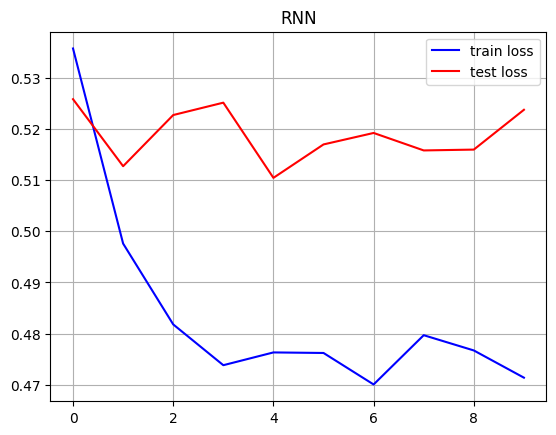

In [28]:
plt.plot(his1.history['loss'], label = 'train loss', color = 'blue')
plt.plot(his1.history['val_loss'], label = 'test loss', color = 'red') 
plt.title('RNN')
plt.legend()
plt.grid()
plt.show()

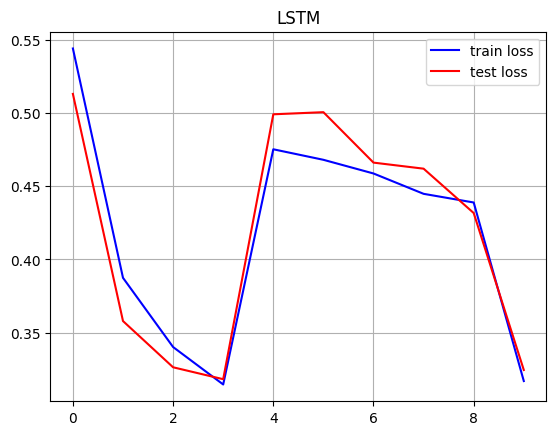

In [29]:
plt.plot(his2.history['loss'], label = 'train loss', color = 'blue')
plt.plot(his2.history['val_loss'], label = 'test loss', color = 'red') 
plt.legend()
plt.title('LSTM')
plt.grid()
plt.show()

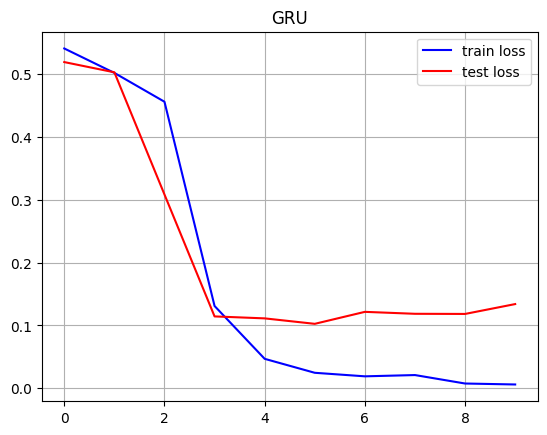

In [30]:
plt.plot(his3.history['loss'], label = 'train loss', color = 'blue')
plt.plot(his3.history['val_loss'], label = 'test loss', color = 'red') 
plt.legend()
plt.title('GRU')
plt.grid()
plt.show()

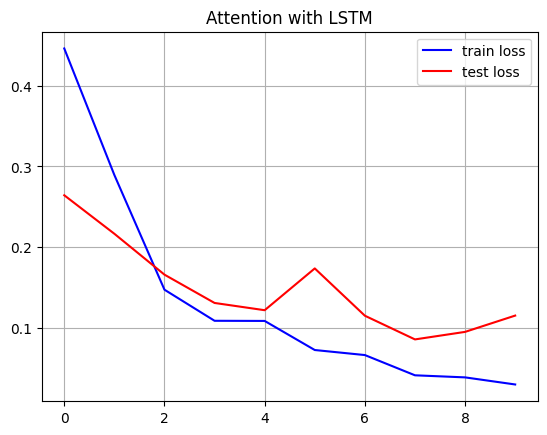

In [31]:
plt.plot(his.history['loss'], label = 'train loss', color = 'blue')
plt.plot(his.history['val_loss'], label = 'test loss', color = 'red') 
plt.legend()
plt.title('Attention with LSTM')
plt.grid()
plt.show()

In [52]:
(model_rnn.predict(x_test_seq) > 0.5).sum()

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


np.int64(75)

In [54]:
np.round(model_rnn.predict(x_test_seq)).sum()

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


np.float32(75.0)

In [56]:
lr_preds = np.round(model.predict(x_test_tokenized))
rnn_preds = np.round(model_rnn.predict(x_test_seq))
lstm_preds = np.round(model_lstm.predict(x_test_seq))
attention_preds = np.round(model_attention.predict(x_test_seq))

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step


In [58]:
results_data = {
    'LogisticRegression': [f1_score(y_test, lr_preds), accuracy_score(y_test, lr_preds)],
    'RNN':  [f1_score(y_test, rnn_preds), accuracy_score(y_test, rnn_preds)],
    'LSTM':  [f1_score(y_test, lstm_preds), accuracy_score(y_test, lstm_preds)],
    'LSTM+Attention':  [f1_score(y_test, attention_preds), accuracy_score(y_test, attention_preds)]
}

In [64]:
pd.DataFrame.from_dict(results_data, orient = 'index', columns = ['f1_score', 'accuracy'])

,f1_score,accuracy
LogisticRegression,0.887574,0.951469
RNN,0.147436,0.773521
LSTM,0.734043,0.851000
LSTM+Attention,0.926099,0.966369


In [65]:
model_rnn2 = Sequential([Embedding(input_dim = max_words, output_dim = 64),
                       SimpleRNN(64, return_sequences=True, dropout = 0.2),
                       GlobalAveragePooling1D(),
                       Dense(1, activation = 'sigmoid')])
model_rnn2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_rnn2.fit(x_train_seq, y_train, batch_size=32, epochs=10, validation_data=(x_test_seq, y_test))
f1_score(y_test, np.round(model_rnn2.predict(x_test_seq)))

Epoch 1/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.8603 - loss: 0.3650 - val_accuracy: 0.9187 - val_loss: 0.2725
Epoch 2/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9377 - loss: 0.2209 - val_accuracy: 0.9395 - val_loss: 0.2065
Epoch 3/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9350 - loss: 0.2238 - val_accuracy: 0.9144 - val_loss: 0.2623
Epoch 4/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9427 - loss: 0.1915 - val_accuracy: 0.9136 - val_loss: 0.2553
Epoch 5/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.9544 - loss: 0.1442 - val_accuracy: 0.9357 - val_loss: 0.1714
Epoch 6/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9562 - loss: 0.1379 - val_accuracy: 0.9174 - val_loss: 0.2793
Epoch 7/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.9613 - loss: 0.1329 - val_accuracy: 0.9417 - val_loss: 0.2002
Epoch 8/10
294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9559 - loss: 0.1151 - 

0.9159049360146252

<b>model_rnn</b> has f1_score = 0.15 and accuracy = 0.77, this meant that for most test cases it predicted 0 ('ham') due to class imbalance (the negative - 0 class dominates over the positives) and got 77% accuracy while having a pretty bad performance underneath.


I added GlobalAveragePooling1D and return_sequences=True. 

1. GlobalAveragePooling averages the 150-word vectors produced by RNN and it helped to memorize patterns both from start, beggining and end as RNNs tend to forget the beggining of a sentence, so this solved the Vanishing Gradient Problem.

2. return sequences = True made the RNN output every single word step in its hidden state while by default it only outputs the last word. Instead of forcing the model to squeeze the meaning of an entire 150-word message into one final vector, it passed a matrix of 150 vectors (one for each word) down the line. This kept the information alive.

By this technique test f1 score got from 0.15 to 0.92, accuracy_score from 0.77 to 0.96

## Overall winner is LSTM wrapped in Attention mechanism

In [79]:
def predict(text):
    text_seq = pad_sequences(tokenizer.texts_to_sequences([text]),maxlen=150, padding = 'post')
    prob = model_attention.predict(text_seq)
    prediction = np.round(prob)
    ans = 'spam' if prediction[0][0]==1 else 'ham'
    return f'{ans} - {prob[0][0]*100:.2f}% probability'
    

In [80]:
predict("""
Make the most of your weekend by investing in yourself. With 40% off a year of Coursera Plus, you can access 10,000+ programs and start building real skills in just a few hours.

Here are a few top courses you can start this weekend:

OpenAI for Beginners (2 hours): Create prompts, enrich data, and generate content using Python and the OpenAI API
Create Your First App with Python & Flask (2 hours): Create a simple web app step by step and bring your ideas to life
Accelerate Your Job Search with AI (6 hours): Use AI tools to strengthen your resume, applications, and job search strategy
Foundations of Digital Marketing & E-commerce (11 hours): Understand how digital marketing works and how businesses grow online
Foundations of Project Management (12 hours): Build core project management skills and learn how to lead projects with confidence
Start something new this weekend and carry that momentum into your week.
""")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


'spam - 65.85% probability'

In [81]:
predict("""
Subject: Quick question regarding the marketing deck for Friday

Hi Alex,

I hope your week is going well!

I’m putting the finishing touches on the project proposal we talked about yesterday, and I wanted to double-check a number with you. Are we still projecting a 15% growth rate for the Q3 digital marketing strategy, or should I adjust that based on the new dataset?

Let me know whenever you have a quick minute. No rush at all!

Best,

Sarah
""")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


'ham - 0.52% probability'